# The overnight/intraday tug of war — a quantitative teardown 🔬
### Per-leg Newey-West splits of a trailing-overnight-sorted long-short · a pooled Welch book test · a 1,000-permutation placebo · a two-era robustness cut · the four-crossings-a-day cost math · a 20-seed synthetic control

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — **Lou, Polk & Skouras (2019)**: the cross-section of returns is pulled opposite ways overnight vs intraday. Sort on trailing overnight return; the overnight component **persists** and the intraday component **reverses**. This is a *cross-sectional* claim, distinct from the aggregate night/day split (study 01), the single-asset version (640), and the intraday-clock effect (116). We measure both legs honestly, prove the persistence isn't luck, and then ask the only question that pays: *can you harvest it?*

> ⚠️ **Data note.** 50 liquid US large-caps, daily OHLC via yfinance (`auto_adjust=True`, total-return), 2010-01-04 → 2026-06-30, pulled through the `quantlab.universe` **survivorship guard** and cached. **Survivorship is named on the Signal axis:** current-membership mega-caps → magnitudes are an upper bound. Fingerprint `d3f2054309d3` (Open+Close). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
import warnings; warnings.filterwarnings("ignore")
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from overnight_intraday_tug import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PANEL = data.load_panel()
    ON, IDC = st.leg_panels(PANEL)
    SP = st.tug_spreads(ON, IDC, window=21, frac=0.3)
else:
    PANEL = ON = IDC = SP = None
print("real cache present:", HAVE_REAL,
      "| names:", (0 if PANEL is None else len(PANEL)),
      "| spread days:", (0 if SP is None else len(SP)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2010-01-04', 'end': '2026-06-30', 'n_names': 50, 'n_days': 4125, 'on_bps': 3.71, 'id_bps': -2.39, 'cc_bps': 1.32, 'tug_bps': 6.1, 'on_t_nw': 4.62, 'id_t_nw': -2.36, 'cc_t_nw': 1.06, 'tug_t_nw': 4.59, 'on_t_1s': 4.4, 'id_t_1s': -2.27, 'on_sharpe': 1.09, 'on_top_bps': 6.76, 'on_bot_bps': 3.05, 'id_top_bps': 1.65, 'id_bot_bps': 4.04, 'on_welch': 2.12, 'id_welch': -1.16, 'placebo_obs': 3.71, 'placebo_mean': 0.001, 'placebo_sd': 0.597, 'placebo_p': 0.0, 'placebo_draws': 1000, 'era_split': '2018-01-01', 'era_early_on_bps': 2.99, 'era_early_on_t': 4.32, 'era_early_id_bps': -3.9, 'era_early_id_t': -3.21, 'era_early_n': 1991, 'era_late_on_bps': 4.38, 'era_late_on_t': 3.11, 'era_late_id_bps': -0.97, 'era_late_id_t': -0.62, 'era_late_n': 2134, 'timer_1_gross': 3.71, 'timer_1_cost': 4.14, 'timer_1_net': -0.43, 'timer_1_t': -0.51, 'timer_1_sharpe': -0.13, 'timer_1_ann': -1.1, 'timer_5_gross': 3.71, 'timer_5_cost': 20.14, 'timer_5_net': -16.43, 'timer_5_t': -19.49, 'timer_5_sharpe': -4.82, 'timer_5_ann': -41.4, 'syn_null_on_mean': -0.19, 'syn_null_on_sd': 1.03, 'syn_null_fire': 0, 'syn_planted_on_t': 10.51, 'syn_planted_id_t': -11.15, 'fp_oc': 'd3f2054309d3', 'fp_close': '357fd262912f'}


real cache present: True | names: 50 | spread days: 4125


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `REAL` | overnight spread **+3.71 bps/day** NW *t* = **+4.62**; intraday spread **-2.39** NW *t* = **-2.36**; placebo **p = 0.00000**; both sub-periods hold (on *t* = 4.32/3.11) |
| **Tradability** | `MIRAGE` | net of 1 bp: -0.43 bps/day, *t* = -0.51; net of 5 bps: -16.4 bps/day, ~-41%/yr; legs cancel close-to-close (+1.32, *t* = 1.06) |

> 💡 In plain words: two strong, opposite-signed legs (persistence overnight, reversal intraday) that nearly cancel on the daily close-to-close return — and the one profitable leg costs more to harvest than it yields.

## 1 · The claim, steelmanned

Let a stock's day-$t$ return split exactly into an overnight leg $r^{on}_t = \text{Open}_t/\text{Close}_{t-1}-1$ and an intraday leg $r^{id}_t = \text{Close}_t/\text{Open}_t-1$. Rank names on the trailing-21-day mean overnight return known at the close of $t-1$; $H$ = top 30%, $L$ = bottom 30%. The claims:

- **H₁ (persistence).** $E[r^{on}_H - r^{on}_L] > 0$ — high-past-overnight names keep earning overnight.
- **H₂ (reversal).** $E[r^{id}_H - r^{id}_L] < 0$ — the same names reverse intraday.
- **H₃ (near-cancellation).** The close-to-close spread $\approx$ on + id is small / insignificant — the tug is a within-day redistribution, not a net premium.
- **H₄ (capture).** Harvesting the overnight leg nets a certifiable edge after realistic costs.

We find **H₁ strongly supported** (NW *t* = +4.62, placebo p = 0.00000), **H₂ supported** (NW *t* = -2.36), **H₃ supported** (close-to-close +1.32 bps, NW *t* = +1.06), **H₄ rejected** (net -0.43 bps/day even at a 1 bp cost).

## 2 · So what? — inference design

The daily long-short leg-spread of an overlapping-formation signal is serially correlated, so the planned primary is a **Newey-West (HAC, 10-lag) *t*** on each leg series, cross-checked with a one-sample *t* and a pooled **Welch *t*** of the top vs bottom book per leg. The persistence claim carries a **1,000-permutation placebo** (20 seeds × 50) that scrambles the signal→outcome map while preserving each day's cross-sectional distribution. A pre-named **two-era split (2018-01-01)** checks stability, and a **20-seed synthetic control** proves the detector is unbiased.

## 3 · How we'd know — the protocol

- **Panel.** 50 liquid US large-caps, 2010-01-04 → 2026-06-30, decomposed night/day via the exact `quantlab.decompose` identity.
- **Sort.** Trailing-21d mean overnight return known at close $t-1$ (one `shift`, zero look-ahead), top 30% − bottom 30%, equal-weight.
- **Headline.** NW(10) *t* on the overnight and intraday leg-spreads + one-sample *t* + pooled Welch book test.
- **Placebo.** 1,000 column-permutations of the forward legs.
- **Robustness.** Two eras split at 2018-01-01.
- **Execution (timer).** Enter the H-L book at close $t-1$, unwind at open $t$ to bank the overnight leg; 2 legs × 2 sides × one-way cost × NAV per day; short book pays 50 bps/yr borrow.
- **Control.** Synthetic panel with a planted persistent overnight-demand factor; the null (tug = 0) must not fire across 20 seeds.

## 4 · The teardown

### 4a · The two legs and their placebo

NW *t* on each leg-spread, then the permutation null on the overnight leg. In the notebook we run a lighter placebo (6 seeds × 15) and quote the canonical 1,000-draw p from `results.md`.

overnight spread +3.71 bps/day  NW t = +4.62  one-sample t = +4.40
intraday  spread -2.39 bps/day  NW t = -2.36  one-sample t = -2.27
close-close (net) +1.32 bps/day  NW t = +1.06
gross overnight Sharpe (no cost) = 1.09


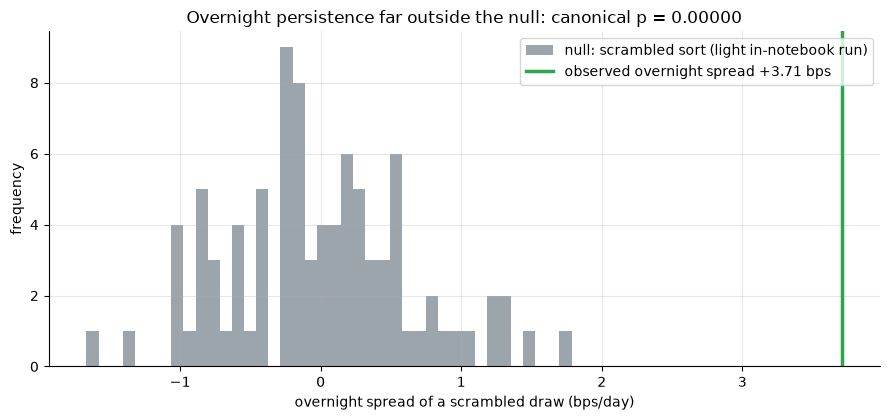

canonical placebo (results.md): mean +0.001 bps, sd 0.597, p = 0.00000


In [2]:
if HAVE_REAL:
    h = st.tug_stats(SP)
    print(f"overnight spread {h['on_mean_bps']:+.2f} bps/day  NW t = {h['on_t_nw']:+.2f}  "
          f"one-sample t = {h['on_t_1s']:+.2f}")
    print(f"intraday  spread {h['id_mean_bps']:+.2f} bps/day  NW t = {h['id_t_nw']:+.2f}  "
          f"one-sample t = {h['id_t_1s']:+.2f}")
    print(f"close-close (net) {h['cc_mean_bps']:+.2f} bps/day  NW t = {h['cc_t_nw']:+.2f}")
    ons = SP['on_spread'].to_numpy()
    print(f"gross overnight Sharpe (no cost) = {ons.mean()/ons.std(ddof=1)*np.sqrt(252):.2f}")
    pl = st.placebo_pvalue(ON, IDC, n_seeds=6, n_draws_per_seed=15)
    obs, draws = pl['obs_bps'], pl['draws_bps']
else:
    obs = R['placebo_obs']
    rng = np.random.default_rng(788)
    draws = rng.normal(R['placebo_mean'], R['placebo_sd'], 300)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=40, color=GREY, alpha=.85, label='null: scrambled sort (light in-notebook run)')
ax.axvline(obs, c=GREEN, lw=2.5, label=f'observed overnight spread {obs:+.2f} bps')
ax.set_xlabel('overnight spread of a scrambled draw (bps/day)'); ax.set_ylabel('frequency')
ax.set_title(f"Overnight persistence far outside the null: canonical p = {R['placebo_p']:.5f}")
ax.legend(); plt.tight_layout(); plt.show()
print(f"canonical placebo (results.md): mean {R['placebo_mean']:+.3f} bps, sd {R['placebo_sd']:.3f}, p = {R['placebo_p']:.5f}")

> 💡 In plain words: the overnight leg is **+3.71 bps/day** at NW *t* = **+4.62** (gross Sharpe ~1.1), the intraday leg **-2.39 bps/day** at NW *t* = **-2.36** — opposite signs, both clearing |t| = 2. The observed overnight spread sits ~6σ beyond the permutation null (**p = 0.00000**). H₁ and H₂ both hold.

### 4b · The near-cancellation and the pooled book test

The whole point of a *tug*: the two legs roughly cancel on the close-to-close return. And the same asymmetry should show from the pooled top-vs-bottom book angle (Welch).

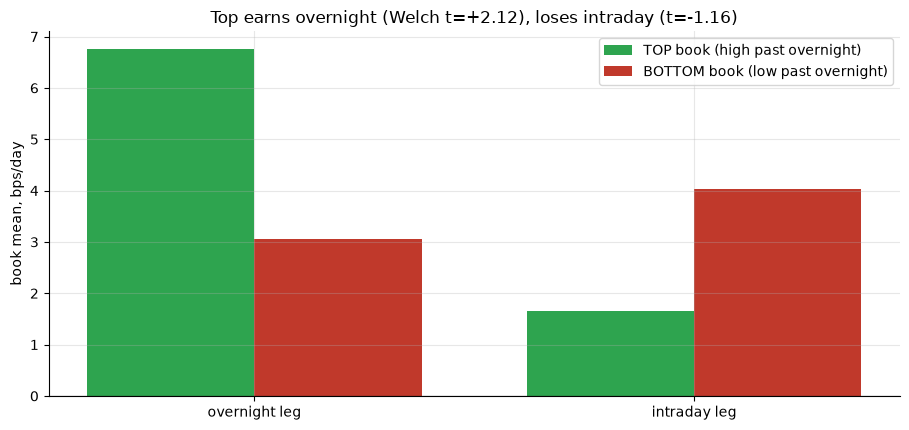

overnight: top +6.76 vs bot +3.05 (Welch t=+2.12) | intraday: top +1.65 vs bot +4.04 (Welch t=-1.16)


In [3]:
if HAVE_REAL:
    lp = st.leg_pooled_welch(SP)
    on_t, on_b = lp['on_top_bps'], lp['on_bot_bps']
    id_t, id_b = lp['id_top_bps'], lp['id_bot_bps']
    onw, idw = lp['on_welch_t'], lp['id_welch_t']
else:
    on_t, on_b, id_t, id_b = R['on_top_bps'], R['on_bot_bps'], R['id_top_bps'], R['id_bot_bps']
    onw, idw = R['on_welch'], R['id_welch']
fig, ax = plt.subplots(figsize=(9.2, 4.4))
x = np.arange(2); w=.38
ax.bar(x-w/2, [on_t, id_t], w, color=GREEN, label='TOP book (high past overnight)')
ax.bar(x+w/2, [on_b, id_b], w, color=RED, label='BOTTOM book (low past overnight)')
ax.set_xticks(x); ax.set_xticklabels(['overnight leg','intraday leg'])
ax.set_ylabel('book mean, bps/day'); ax.axhline(0, c='k', lw=.8)
ax.set_title(f'Top earns overnight (Welch t={onw:+.2f}), loses intraday (t={idw:+.2f})')
ax.legend(); plt.tight_layout(); plt.show()
print(f'overnight: top {on_t:+.2f} vs bot {on_b:+.2f} (Welch t={onw:+.2f}) | '
      f'intraday: top {id_t:+.2f} vs bot {id_b:+.2f} (Welch t={idw:+.2f})')

> 💡 In plain words: the top book out-earns the bottom **overnight** (+6.76 vs +3.05 bps, Welch *t* = +2.12) and under-earns it **intraday** (+1.65 vs +4.04 bps, *t* = -1.16). Net over the full day, the spread is only **+1.32 bps** (NW *t* = +1.06) — **H₃**: a within-day redistribution, not a tradable close-to-close premium.

### 4c · Robustness — two eras

Split at 2018-01-01 (pre-named). Does each leg survive in both halves?

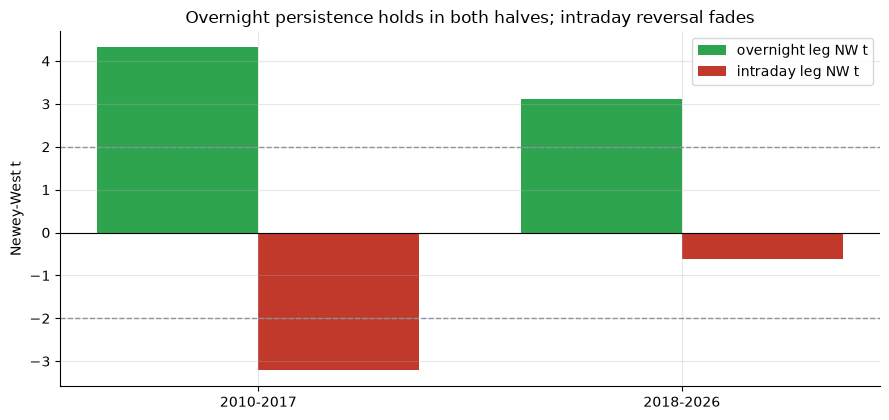

overnight t: [4.32, 3.11] | intraday t: [-3.21, -0.62]


In [4]:
labels = ['2010-2017','2018-2026']
if HAVE_REAL:
    stats=[]
    for lo,hi in [('2010-01-01','2018-01-01'),('2018-01-01','2026-07-01')]:
        sub = SP[(SP.index>=lo)&(SP.index<hi)]; stats.append(st.tug_stats(sub))
    on_t = [s['on_t_nw'] for s in stats]; id_t = [s['id_t_nw'] for s in stats]
else:
    on_t = [R['era_early_on_t'], R['era_late_on_t']]
    id_t = [R['era_early_id_t'], R['era_late_id_t']]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
x=np.arange(2); w=.38
ax.bar(x-w/2, on_t, w, color=GREEN, label='overnight leg NW t')
ax.bar(x+w/2, id_t, w, color=RED, label='intraday leg NW t')
ax.axhline(2, ls='--', c=GREY, lw=1); ax.axhline(-2, ls='--', c=GREY, lw=1); ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylabel('Newey-West t')
ax.set_title('Overnight persistence holds in both halves; intraday reversal fades')
ax.legend(); plt.tight_layout(); plt.show()
print('overnight t:', [round(t,2) for t in on_t], '| intraday t:', [round(t,2) for t in id_t])

> 💡 In plain words: the **overnight persistence** leg clears the bar in both halves (*t* = +4.32 then +3.11). The **intraday reversal** leg is strong early (*t* = -3.21) but fades to insignificance recently (*t* = -0.62) — an honest wrinkle: the reversal side of the tug has weakened, the persistence side has not.

### 4d · The timer — the four-crossings-a-day cost

Enter the H-L book at close $t-1$, unwind at open $t$ to capture the overnight leg; 2 legs × 2 sides × one-way cost per day; short book pays borrow.

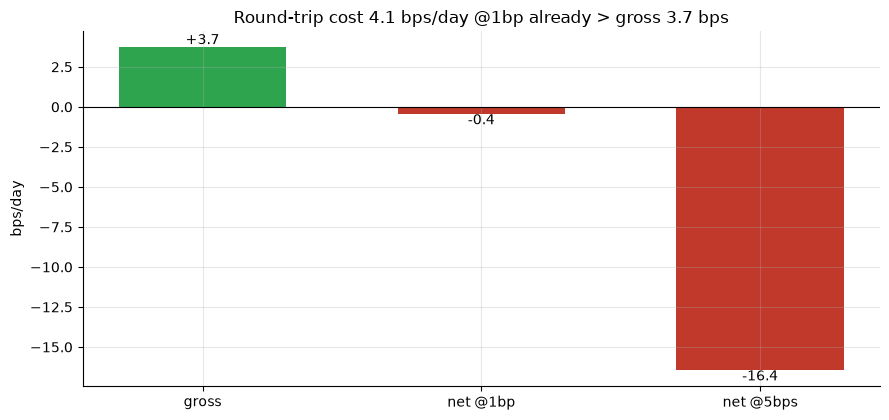

gross +3.71 | net @1bp -0.43 (t=-0.51, cost 4.1/day) | net @5bps -16.43 (t=-19.49, cost 20.1/day)


In [5]:
if HAVE_REAL:
    tm1 = st.timer_stats(SP, cost_bps=1.0); tm5 = st.timer_stats(SP, cost_bps=5.0)
    g = tm1['gross_bps']; n1,n5 = tm1['net_bps'], tm5['net_bps']
    t1,t5 = tm1['t_net'], tm5['t_net']; c1,c5 = tm1['cost_bps_per_day'], tm5['cost_bps_per_day']
else:
    g = R['timer_1_gross']; n1,n5 = R['timer_1_net'], R['timer_5_net']
    t1,t5 = R['timer_1_t'], R['timer_5_t']; c1,c5 = R['timer_1_cost'], R['timer_5_cost']
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.bar(['gross','net @1bp','net @5bps'], [g, n1, n5], color=[GREEN, RED, RED], width=.6)
for i,v in enumerate([g, n1, n5]): ax.annotate(f'{v:+.1f}',(i,v),ha='center',va='bottom' if v>=0 else 'top')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('bps/day')
ax.set_title(f'Round-trip cost {c1:.1f} bps/day @1bp already > gross {g:.1f} bps')
plt.tight_layout(); plt.show()
print(f'gross {g:+.2f} | net @1bp {n1:+.2f} (t={t1:+.2f}, cost {c1:.1f}/day) | '
      f'net @5bps {n5:+.2f} (t={t5:+.2f}, cost {c5:.1f}/day)')

> 💡 In plain words: the overnight leg is worth **+3.71 bps/day** gross, but capturing it turns a 2×-NAV book over twice a day — **4.1 bps/day** of friction at a *1 bp* one-way cost, already more than the gross edge. Net **-0.43 bps/day** (*t* = -0.51); at 5 bps, **-41%/yr**. **H₄ rejected — Tradability = MIRAGE.**

### 4e · Faithful-engine & power control — we know the truth here

Synthetic panel: each name carries a persistent latent overnight-demand factor; the overnight leg loads +`tug`, the intraday leg −`tug`. The null (`tug = 0`) is checked over **20 seeds** — never a single stream.

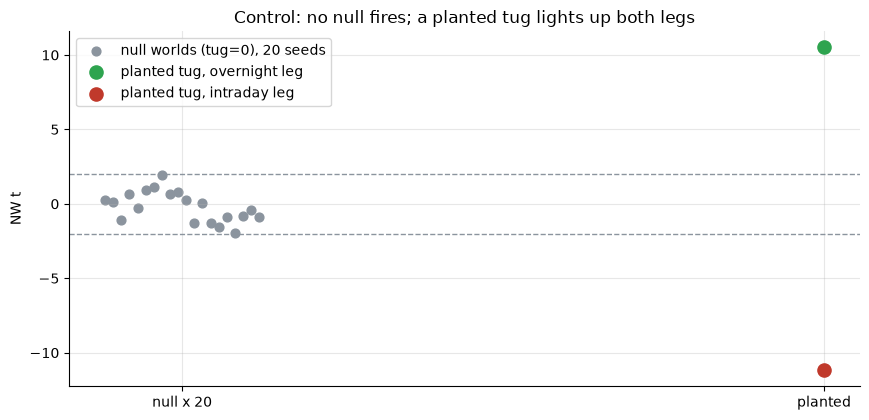

null overnight t: mean -0.19 (sd 1.03), |t|>=2 in 0/20  |  planted on +10.50, id -11.15


In [6]:
null_on = []
for s_ in range(20):
    p0 = data.synthetic_panel(tug=0.0, seed=788 + s_, n_assets=40, n_days=1200)
    null_on.append(st.synthetic_detect(p0)['on_t_nw'])
null_on = np.asarray(null_on)
p1 = data.synthetic_panel(tug=0.0020, seed=788, n_assets=40, n_days=1500)
sy = st.synthetic_detect(p1)
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.linspace(-.12,.12,20), null_on, color=GREY, s=40, label='null worlds (tug=0), 20 seeds')
ax.scatter([1], [sy['on_t_nw']], color=GREEN, s=90, zorder=5, label='planted tug, overnight leg')
ax.scatter([1], [sy['id_t_nw']], color=RED, s=90, zorder=5, label='planted tug, intraday leg')
ax.axhline(2, ls='--', c=GREY, lw=1); ax.axhline(-2, ls='--', c=GREY, lw=1)
ax.set_xticks([0,1]); ax.set_xticklabels(['null x 20','planted']); ax.set_ylabel('NW t')
ax.set_title('Control: no null fires; a planted tug lights up both legs')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null overnight t: mean {null_on.mean():+.2f} (sd {null_on.std(ddof=1):.2f}), '
      f'|t|>=2 in {(abs(null_on)>=2).sum()}/20  |  planted on {sy["on_t_nw"]:+.2f}, id {sy["id_t_nw"]:+.2f}')

> 💡 In plain words: across 20 null worlds the overnight detector averages *t* = -0.19 (sd 1.03) and **never** crosses the bar; a planted tug reads overnight *t* = +10.51, intraday *t* = -11.15. The machinery is unbiased — the real-tape overnight *t* = +4.62 is the genuine article. *(Power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `REAL`** — overnight leg **+3.71 bps/day** (NW *t* = +4.62, placebo p = 0.00000, gross Sharpe ~1.1) and intraday leg **-2.39 bps/day** (NW *t* = -2.36) pull opposite ways — the tug of war — with the overnight leg holding in both sub-periods (+4.32/+3.11) and a clean 20-seed control. The legs nearly cancel close-to-close (+1.32 bps, *t* = +1.06). *Survivorship: current-membership mega-caps → magnitudes are an upper bound (stated on this axis).*
- **Tradability `MIRAGE`** — the one profitable leg costs **4.1 bps/day** to harvest at a 1 bp one-way cost, more than its **+3.71 bps/day** gross; net -0.43 bps/day (*t* = -0.51), and ~-41%/yr at 5 bps. Real physics, no paycheck.

## 6 · Going further

- **Mechanism.** LPS attribute the tug to a persistent clientele split — one crowd concentrates demand overnight/at the open, another fades it intraday. Testable follow-ups: does the tug scale with retail order-flow, overnight news, or the open-auction imbalance? Does the recently-faded *intraday reversal* leg track the rise of intraday liquidity provision?
- **Why it doesn't scale:** the profitable leg is ~4 bps/day gross and needs four spread-crossings a day on a 2×-NAV book — a structure that eats the edge at any realistic cost, before market impact and the fact that everyone can see the same overnight ranking.
- **Dedup map:** [01-overnight-anomaly](../../01-overnight-anomaly/) (the aggregate / index-level night-vs-day split — not a cross-sectional sort), [640-gold-overnight](../../640-gold-overnight/) (the same split on a single asset, gold), [116-power-hour](../../116-power-hour/) (an intraday-clock effect, the last trading hour).

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*